In [1]:
import pandas as pd
import sqlite3

## Ex00
- Установи соединение с базой данных (той же, что и в предыдущий день).
- Выполни запрос к таблице pageviews, получив столбец datetime только для пользователей (без админов).
- С помощью Pandas создай новый DataFrame, в котором визиты посчитаны и сгруппированы по дате.
- Используя метод Pandas .plot(), построй график.
    - Размер шрифта — 8.
    - Размер фигуры — (15, 8).
    - Заголовок графика — "Views per day".
    - Обрати внимание на поворот меток по оси X (xticks) на графике ниже.
- Закрой соединение с базой данных.

In [2]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [3]:
pageviews = pd.io.sql.read_sql(
    """
    SELECT datetime
    FROM pageviews
    WHERE uid LIKE 'user%'
    ORDER BY datetime;
    """,
    conn,
    parse_dates = ['datetime']
)
print('===Даты посещения пользователей===')
pageviews

===Даты посещения пользователей===


,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


In [4]:
pageviews['date'] = pageviews['datetime'].dt.date
pageviews

,datetime,date
0,2020-04-17 22:46:26.785035,2020-04-17
1,2020-04-18 10:53:52.623447,2020-04-18
2,2020-04-18 10:56:55.833899,2020-04-18
3,2020-04-18 10:57:37.331258,2020-04-18
4,2020-04-18 12:05:48.200144,2020-04-18
...,...,...
982,2020-05-21 18:45:20.441142,2020-05-21
983,2020-05-21 23:03:06.457819,2020-05-21
984,2020-05-21 23:23:49.995349,2020-05-21
985,2020-05-22 11:30:18.368990,2020-05-22


In [5]:
daily_visits = pageviews.groupby('date').size().reset_index(name='views')
daily_visits

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


<Axes: title={'center': 'Views per day'}, xlabel='date'>

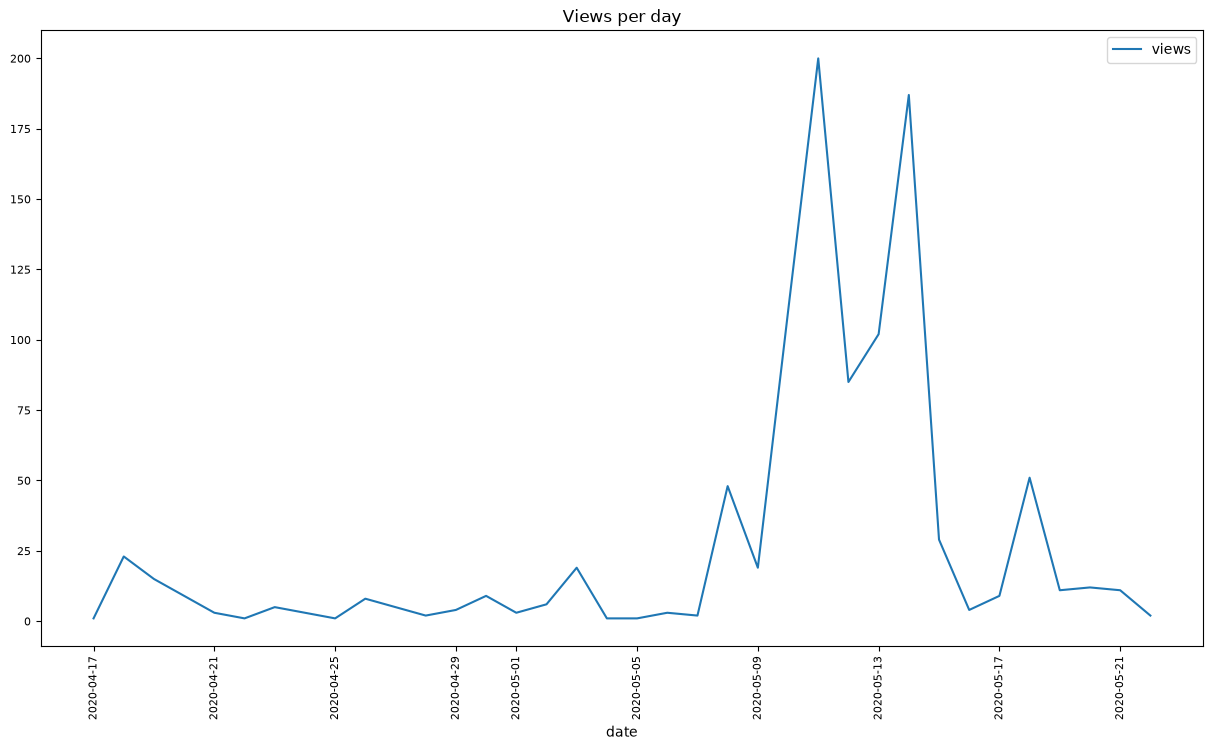

In [6]:
daily_visits.set_index('date').plot(
    title='Views per day',
    fontsize=8,
    figsize=(15,8),
    rot=90
)

In [7]:
conn.close()